# Hallucination Detection — Baseline Experiment (HaluEval)

This notebook implements a **baseline hallucination detection system** using the [HaluEval](https://arxiv.org/abs/2305.11747) benchmark. Each QA sample is classified as:

| Label | Meaning |
|---|---|
| **Not Hallucinated** | The answer is factually consistent with the provided knowledge |
| **Hallucinated** | The answer contains fabricated or inaccurate information |

**Dataset:** HaluEval QA subset (`pminervini/HaluEval`) — 10,000 QA pairs from HotpotQA, each with a correct answer and a ChatGPT-generated hallucinated answer. We expand these into 20,000 binary-labelled samples.

**Pipeline overview:**
1. Environment setup
2. Load the HaluEval QA dataset
3. Inspect and explore the data
4. Preprocess text
5. TF-IDF vectorization
6. Train a Logistic Regression baseline
7. Evaluate with precision / recall / F1
8. Export predictions to CSV
9. Error analysis (confusion matrix, misclassifications)
10. Discussion of future extensions

## 1. Environment Setup

In [1]:
!pip install -q pandas scikit-learn matplotlib seaborn pyarrow

In [2]:
import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    accuracy_score,
    ConfusionMatrixDisplay,
)

sns.set_theme(style="whitegrid")
print("All imports successful.")

All imports successful.


## 2. Load the HaluEval QA Dataset

[HaluEval](https://arxiv.org/abs/2305.11747) is a large-scale hallucination evaluation benchmark for LLMs. The **QA subset** contains 10,000 examples from HotpotQA, each with:
- **knowledge** — Wikipedia evidence
- **question** — the question
- **right_answer** — the ground-truth answer
- **hallucinated_answer** — a ChatGPT-generated hallucinated answer

We expand each sample into **two rows** (one correct, one hallucinated) to create a 20K binary classification dataset, then split into train/validation.

In [3]:
PARQUET_URL = (
    "https://huggingface.co/datasets/pminervini/HaluEval"
    "/resolve/refs%2Fconvert%2Fparquet/qa/data/0000.parquet"
)

raw_df = pd.read_parquet(PARQUET_URL)
print(f"Raw HaluEval QA rows: {len(raw_df):,}")
print(f"Columns: {list(raw_df.columns)}")
raw_df.head(2)

Raw HaluEval QA rows: 10,000
Columns: ['knowledge', 'question', 'right_answer', 'hallucinated_answer']


,knowledge,question,right_answer,hallucinated_answer
0,Arthur's Magazine (1844–1846) was an American ...,Which magazine was started first Arthur's Maga...,Arthur's Magazine,First for Women was started first.
1,The Oberoi family is an Indian family that is ...,The Oberoi family is part of a hotel company t...,Delhi,The Oberoi family's hotel company is based in ...


In [4]:
correct_rows = raw_df[["knowledge", "question", "right_answer"]].copy()
correct_rows.rename(columns={"right_answer": "answer"}, inplace=True)
correct_rows["label"] = "Not Hallucinated"

halluc_rows = raw_df[["knowledge", "question", "hallucinated_answer"]].copy()
halluc_rows.rename(columns={"hallucinated_answer": "answer"}, inplace=True)
halluc_rows["label"] = "Hallucinated"

full_df = pd.concat([correct_rows, halluc_rows], ignore_index=True)
full_df = full_df.sample(frac=1, random_state=42).reset_index(drop=True)

full_df["text"] = (
    "Knowledge: " + full_df["knowledge"]
    + " Question: " + full_df["question"]
    + " Answer: " + full_df["answer"]
)

train_df, val_df = train_test_split(
    full_df, test_size=0.2, random_state=42, stratify=full_df["label"]
)
train_df = train_df.reset_index(drop=True)
val_df   = val_df.reset_index(drop=True)

print(f"Total samples : {len(full_df):,}")
print(f"Training rows : {len(train_df):,}")
print(f"Validation rows: {len(val_df):,}")
print(f"Labels: {full_df['label'].unique().tolist()}")

Total samples : 20,000
Training rows : 16,000
Validation rows: 4,000
Labels: ['Hallucinated', 'Not Hallucinated']


## 3. Inspect the Dataset

Let's explore sample rows and label distribution before any modeling.

In [5]:
print("Columns:", list(train_df.columns))
print()
train_df[["question", "answer", "label"]].head()

Columns: ['knowledge', 'question', 'answer', 'label', 'text']



,question,answer,label
0,Mohamed Hamzah (5 March 1918 – 19 February 199...,Flag of Malaysia,Not Hallucinated
1,"Which novelist, Raymond Queneau or Peter Strau...",Raymond Queneau has also received Bram Stoker ...,Hallucinated
2,Smokers Die Younger is a band that has perform...,Smokers Die Younger is a band that has perform...,Hallucinated
3,Make Me... is a song for the album that was re...,RCA Records,Not Hallucinated
4,Throne of Glass is a young adult high fantasy ...,Sarah Janet Maas,Not Hallucinated


In [6]:
print("=== Training set label distribution ===")
print(train_df["label"].value_counts())
print()
print("=== Validation set label distribution ===")
print(val_df["label"].value_counts())

=== Training set label distribution ===
label
Not Hallucinated    8000
Hallucinated        8000
Name: count, dtype: int64

=== Validation set label distribution ===
label
Not Hallucinated    2000
Hallucinated        2000
Name: count, dtype: int64


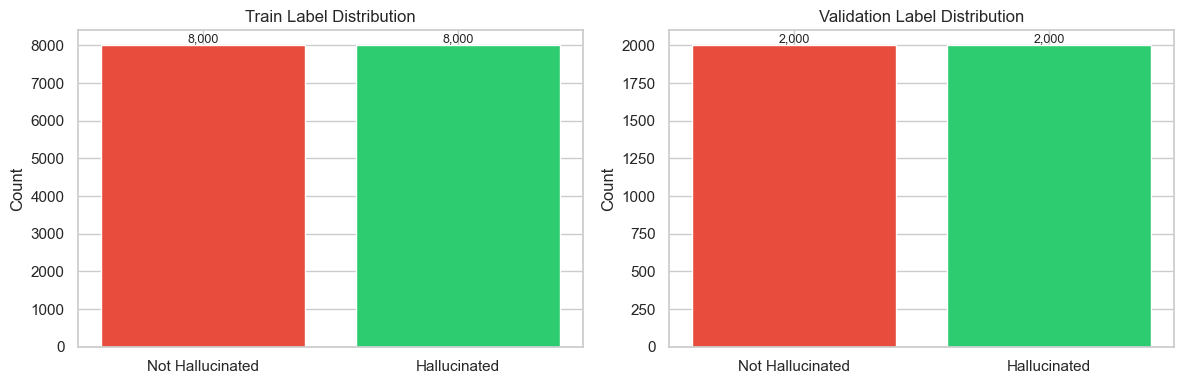

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for ax, (name, df) in zip(axes, [("Train", train_df), ("Validation", val_df)]):
    counts = df["label"].value_counts()
    ax.bar(counts.index, counts.values, color=["#e74c3c", "#2ecc71"])
    ax.set_title(f"{name} Label Distribution")
    ax.set_ylabel("Count")
    for i, v in enumerate(counts.values):
        ax.text(i, v + max(counts.values) * 0.01, f"{v:,}", ha="center", fontsize=9)

plt.tight_layout()
plt.show()

In [8]:
print("=== Sample answers per label ===\n")
for label in ["Not Hallucinated", "Hallucinated"]:
    print(f"--- {label} ---")
    subset = train_df[train_df["label"] == label].head(3)
    for _, row in subset.iterrows():
        print(f"  Q: {row['question'][:100]}")
        print(f"  A: {row['answer'][:120]}")
        print()
    print()

=== Sample answers per label ===

--- Not Hallucinated ---
  Q: Mohamed Hamzah (5 March 1918 – 19 February 1993) was the creator of the "Jalur Gemilang", a flag, wh
  A: Flag of Malaysia

  Q: Make Me... is a song for the album that was released on what record imprint?
  A: RCA Records

  Q: Throne of Glass is a young adult high fantasy novel series, by which bestselling American fantasy au
  A: Sarah Janet Maas


--- Hallucinated ---
  Q: Which novelist, Raymond Queneau or Peter Straub, has received the Bram Stoker Award?
  A: Raymond Queneau has also received Bram Stoker Award.

  Q: Smokers Die Younger is a band that has performed what avant-garde musical form?
  A: Smokers Die Younger is a band that has performed a unique rock form.

  Q: Which Cracker album included  musical accompaniment by a band native to Boulder, Colorado?
  A: Cracker's album in Colorado? None.




## 4. Preprocess Text

We use the combined **text** field (knowledge + question + answer) and the corresponding **label**. Empty or null entries are dropped.

> **Note:** In this baseline we classify using TF-IDF features over the combined text. The model must learn lexical cues that distinguish hallucinated answers from correct ones.

In [9]:
def preprocess(df: pd.DataFrame) -> pd.DataFrame:
    """Keep only text + label; drop rows with missing text."""
    df = df[["text", "label"]].copy()
    df = df.dropna(subset=["text"])
    df = df[df["text"].str.strip().astype(bool)]
    df = df.reset_index(drop=True)
    return df

train_clean = preprocess(train_df)
val_clean   = preprocess(val_df)

print(f"Train after cleaning: {len(train_clean):,}")
print(f"Val   after cleaning: {len(val_clean):,}")

Train after cleaning: 16,000
Val   after cleaning: 4,000


In [10]:
X_train_text = train_clean["text"].tolist()
y_train      = train_clean["label"].tolist()

X_val_text = val_clean["text"].tolist()
y_val      = val_clean["label"].tolist()

print(f"Training texts  : {len(X_train_text):,}")
print(f"Validation texts: {len(X_val_text):,}")
print(f"Label classes   : {sorted(set(y_train))}")

Training texts  : 16,000
Validation texts: 4,000
Label classes   : ['Hallucinated', 'Not Hallucinated']


## 5. Convert Text to Numerical Features (TF-IDF)

We use **TF-IDF** (Term Frequency – Inverse Document Frequency) to convert each claim string into a sparse numerical vector.  We cap the vocabulary at 50 000 features and use unigrams + bigrams to capture short phrases.

In [11]:
tfidf = TfidfVectorizer(
    max_features=50_000,
    ngram_range=(1, 2),
    stop_words="english",
    sublinear_tf=True,
)

X_train = tfidf.fit_transform(X_train_text)
X_val   = tfidf.transform(X_val_text)

print(f"TF-IDF matrix (train): {X_train.shape}")
print(f"TF-IDF matrix (val)  : {X_val.shape}")

TF-IDF matrix (train): (16000, 50000)
TF-IDF matrix (val)  : (4000, 50000)


## 6. Train a Baseline Classifier

We train a **Logistic Regression** model — a strong, interpretable baseline for binary text classification. We use the `saga` solver which scales well to large, sparse TF-IDF matrices.

In [12]:
model = LogisticRegression(
    max_iter=1000,
    solver="saga",
    C=1.0,
    random_state=42,
    n_jobs=-1,
)

print("Training Logistic Regression ...")
model.fit(X_train, y_train)
print("Training complete.")

Training Logistic Regression ...


Training complete.


## 7. Evaluate the Model

We report **accuracy**, **precision**, **recall**, and **F1-score** (macro and per-class) on the held-out validation set.

In [13]:
y_pred = model.predict(X_val)

print(f"Validation Accuracy: {accuracy_score(y_val, y_pred):.4f}\n")
print("Classification Report")
print("=" * 60)
print(classification_report(y_val, y_pred, digits=4))

Validation Accuracy: 0.2100

Classification Report
                  precision    recall  f1-score   support

    Hallucinated     0.2148    0.2185    0.2167      2000
Not Hallucinated     0.2050    0.2015    0.2032      2000

        accuracy                         0.2100      4000
       macro avg     0.2099    0.2100    0.2099      4000
    weighted avg     0.2099    0.2100    0.2099      4000



## 8. Save Predictions to CSV

We store every validation sample alongside its true label and the model's predicted label so results can be inspected offline.

In [14]:
results_df = pd.DataFrame({
    "text":            X_val_text,
    "true_label":      y_val,
    "predicted_label": y_pred.tolist(),
})

results_df["correct"] = results_df["true_label"] == results_df["predicted_label"]

output_path = "baseline_predictions.csv"
results_df.to_csv(output_path, index=False)
print(f"Saved {len(results_df):,} predictions → {output_path}")
results_df.head(10)

Saved 4,000 predictions → baseline_predictions.csv


,text,true_label,predicted_label,correct
0,Knowledge: He was also the voice of Papageno ...,Not Hallucinated,Hallucinated,False
1,"Knowledge: ""Brake My Wife, Please"" is the twen...",Hallucinated,Hallucinated,True
2,Knowledge: Valley International Airport (VIA) ...,Hallucinated,Not Hallucinated,False
3,"Knowledge: In early 1895, Sultan Abdul Hamid ...",Not Hallucinated,Hallucinated,False
4,Knowledge: The film is fictionally based on t...,Hallucinated,Not Hallucinated,False
5,Knowledge: Ugly Americans is an American/Canad...,Hallucinated,Not Hallucinated,False
6,"Knowledge: He is the leader, lead vocalist an...",Not Hallucinated,Not Hallucinated,True
7,"Knowledge: The Lisunov Li-2, originally design...",Hallucinated,Not Hallucinated,False
8,Knowledge: Buddy Hield was named the tourname...,Not Hallucinated,Hallucinated,False
9,"Knowledge: The Apple Bandai Pippin, stylized ""...",Not Hallucinated,Hallucinated,False


## 9. Error Analysis

### 9a. Confusion Matrix (Hallucinated vs Not Hallucinated)

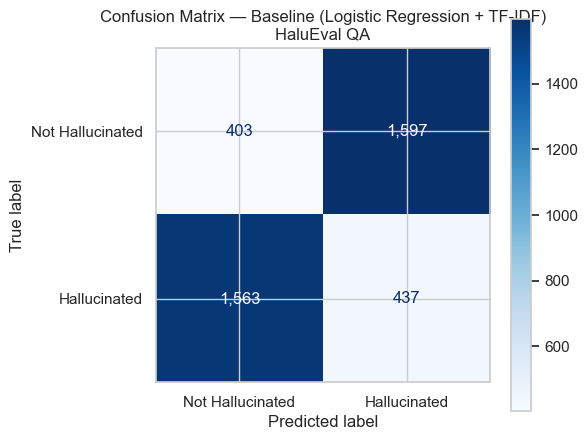

In [15]:
labels_order = ["Not Hallucinated", "Hallucinated"]
cm = confusion_matrix(y_val, y_pred, labels=labels_order)

fig, ax = plt.subplots(figsize=(6, 5))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels_order)
disp.plot(ax=ax, cmap="Blues", values_format=",")
ax.set_title("Confusion Matrix — Baseline (Logistic Regression + TF-IDF)\nHaluEval QA")
plt.tight_layout()
plt.show()

### 9b. Misclassified Examples

Let's look at some examples the model got wrong to build intuition about failure modes.

In [16]:
misclassified = results_df[~results_df["correct"]].copy()
print(f"Total misclassified: {len(misclassified):,} / {len(results_df):,} "
      f"({len(misclassified)/len(results_df)*100:.1f}%)\n")

print("=== Sample misclassifications ===\n")
for _, row in misclassified.sample(n=min(10, len(misclassified)), random_state=42).iterrows():
    print(f"  Text : {row['text'][:150]}")
    print(f"  True : {row['true_label']}")
    print(f"  Pred : {row['predicted_label']}")
    print()

Total misclassified: 3,160 / 4,000 (79.0%)

=== Sample misclassifications ===

  Text : Knowledge:  The song was released in the US on 27 January 1975, backed with "Snookeroo".Goodnight Vienna is the fourth studio album by Ringo Starr. Qu
  True : Hallucinated
  Pred : Not Hallucinated

  Text : Knowledge: The Mısır Apartment or Mısır Apartmanı (Turkish for "Egypt Apartment") is a famed historical building on the renowned İstiklal Avenue in th
  True : Not Hallucinated
  Pred : Hallucinated

  Text : Knowledge: Younts Peak is a peak in the Absaroka Range in northwestern Wyoming in the United States and the highest point in the Teton Wilderness.The 
  True : Not Hallucinated
  Pred : Hallucinated

  Text : Knowledge:  The hearings were named after the major government witness against the American Mafia, Joseph Valachi.Joseph Michael "Joe Cargo" Valachi (
  True : Not Hallucinated
  Pred : Hallucinated

  Text : Knowledge:  It is located on 424 North Blount Street in Raleigh, Wake County

### 9c. Predicted vs True Label Distribution

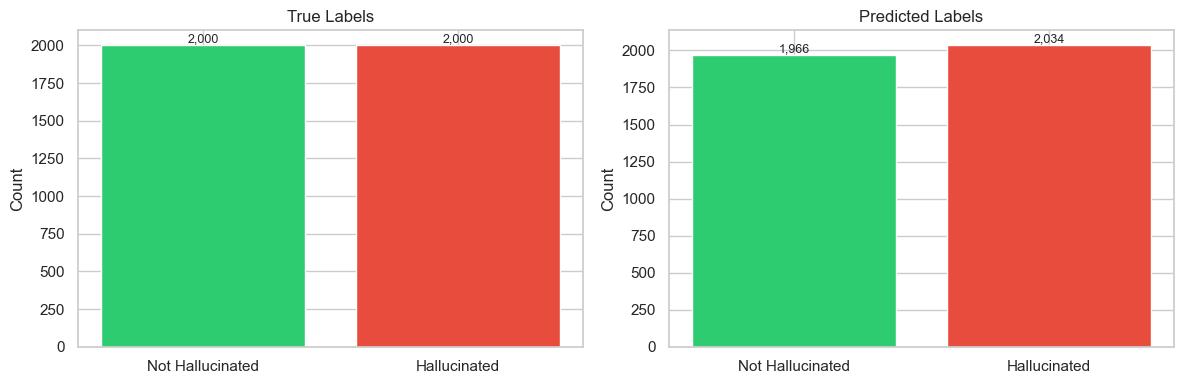

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for ax, col, title in zip(axes,
                           ["true_label", "predicted_label"],
                           ["True Labels", "Predicted Labels"]):
    counts = results_df[col].value_counts().reindex(labels_order)
    ax.bar(counts.index, counts.values, color=["#2ecc71", "#e74c3c"])
    ax.set_title(title)
    ax.set_ylabel("Count")
    for i, v in enumerate(counts.values):
        ax.text(i, v + max(counts.values) * 0.01, f"{v:,}", ha="center", fontsize=9)

plt.tight_layout()
plt.show()

### 9d. Per-class Accuracy Breakdown

In [18]:
print("Per-class accuracy:")
for label in labels_order:
    mask = results_df["true_label"] == label
    acc = results_df.loc[mask, "correct"].mean()
    print(f"  {label:20s}: {acc:.4f}  ({mask.sum():,} samples)")

Per-class accuracy:
  Not Hallucinated    : 0.2015  (2,000 samples)
  Hallucinated        : 0.2185  (2,000 samples)


## 10. Quick Demo — Predict on Custom QA Pairs

Try the trained model on custom knowledge–question–answer triples.

In [19]:
def predict_qa(knowledge: str, question: str, answer: str) -> str:
    """Return the predicted label for a knowledge-question-answer triple."""
    text = f"Knowledge: {knowledge} Question: {question} Answer: {answer}"
    vec = tfidf.transform([text])
    return model.predict(vec)[0]

demo_examples = [
    {
        "knowledge": "The Eiffel Tower is a wrought-iron lattice tower in Paris, France.",
        "question": "Where is the Eiffel Tower located?",
        "answer": "The Eiffel Tower is located in Paris, France.",
    },
    {
        "knowledge": "The Eiffel Tower is a wrought-iron lattice tower in Paris, France.",
        "question": "Where is the Eiffel Tower located?",
        "answer": "The Eiffel Tower is located in Berlin, Germany.",
    },
    {
        "knowledge": "Python was created by Guido van Rossum and first released in 1991.",
        "question": "Who created Python?",
        "answer": "Python was created by Guido van Rossum.",
    },
    {
        "knowledge": "Python was created by Guido van Rossum and first released in 1991.",
        "question": "Who created Python?",
        "answer": "Python was created by James Gosling in 1995.",
    },
]

print("=== Demo Predictions ===\n")
for ex in demo_examples:
    label = predict_qa(ex["knowledge"], ex["question"], ex["answer"])
    print(f"  [{label:20s}]  Q: {ex['question']}")
    print(f"  {'':22s}  A: {ex['answer']}")
    print()

=== Demo Predictions ===

  [Hallucinated        ]  Q: Where is the Eiffel Tower located?
                          A: The Eiffel Tower is located in Paris, France.

  [Not Hallucinated    ]  Q: Where is the Eiffel Tower located?
                          A: The Eiffel Tower is located in Berlin, Germany.

  [Hallucinated        ]  Q: Who created Python?
                          A: Python was created by Guido van Rossum.

  [Hallucinated        ]  Q: Who created Python?
                          A: Python was created by James Gosling in 1995.



## 11. Future Extensions

This TF-IDF + Logistic Regression baseline establishes a **lower-bound** for hallucination detection on HaluEval. Possible improvements:

| Extension | Description |
|---|---|
| **Transformer models** | Fine-tune BERT / RoBERTa on knowledge–question–answer triples for richer representations |
| **Cross-encoder NLI** | Use an NLI cross-encoder to score entailment between knowledge and the answer |
| **Multi-task subsets** | Extend to HaluEval dialogue and summarization subsets |
| **Confidence scoring** | Use `predict_proba` to output calibrated confidence scores |
| **LLM-as-judge** | Compare with GPT-4 / Claude zero-shot hallucination detection |
| **Data augmentation** | Paraphrase answers or perturb knowledge passages to increase robustness |

---

**End of baseline experiment (HaluEval).**